
#  Online Retail – Preprocessing Pipeline for Clustering

In [ ]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

sns.set(rc={'axes.facecolor': '#f5f5f5'}, style='darkgrid')
ORANGE = '#ff6200'
BLUE   = '#1a6fb5'


In [ ]:
import gdown
import pandas as pd

file_id = '1esY-i8CZ53Rb4YsH-PX2Pdotc181K6ta'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'online_retail.csv'

gdown.download(url, output, quiet=False)

df = pd.read_csv('online_retail.csv')

Downloading...
From: https://drive.google.com/uc?id=1esY-i8CZ53Rb4YsH-PX2Pdotc181K6ta
To: /content/online_retail.csv
100%|██████████| 48.0M/48.0M [00:00<00:00, 157MB/s]


In [ ]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Cleaning

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:


df = df.dropna(subset=['CustomerID', 'Description'])

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
#======> Finding duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [ ]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f"    Removed {before - len(df):,} fully identical rows")


    Removed 5,225 fully identical rows


In [ ]:
# Getting the number of rows in the dataframe
df.shape[0]

401604

In [ ]:
 #======> DATA TYPES

# CustomerID arrived as float (e.g. 17850.0)
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

# InvoiceDate is already datetime?
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])              #يطلع منه بعدين فيتشر زمنيه
print(f"    CustomerID  : float → string  (sample: {df['CustomerID'].iloc[0]})")
print(f"    InvoiceDate : {df['InvoiceDate'].dtype}")


    CustomerID  : float → string  (sample: 17850)
    InvoiceDate : datetime64[ns]


In [ ]:

#======> Treating Cancelled Transactions (FEATURE ENG)

print("\n Cancelled Transactions")
df['Is_Cancelled'] = df['InvoiceNo'].astype(str).str.startswith('C').astype(int)
n_cancelled = df['Is_Cancelled'].sum()
print(f"    Cancelled rows   : {n_cancelled:,}  ({n_cancelled/len(df)*100:.2f}%)")
print("    Retained for cancellation-rate feature engineering (not dropped).") # CB




 Cancelled Transactions
    Cancelled rows   : 8,872  (2.21%)
    Retained for cancellation-rate feature engineering (not dropped).


In [ ]:
# ========> STOCKCODE ANOMALIES

unique_stock_codes = df['StockCode'].nunique()
print(f"The number of unique stock codes in the dataset is: {unique_stock_codes}")

The number of unique stock codes in the dataset is: 3684


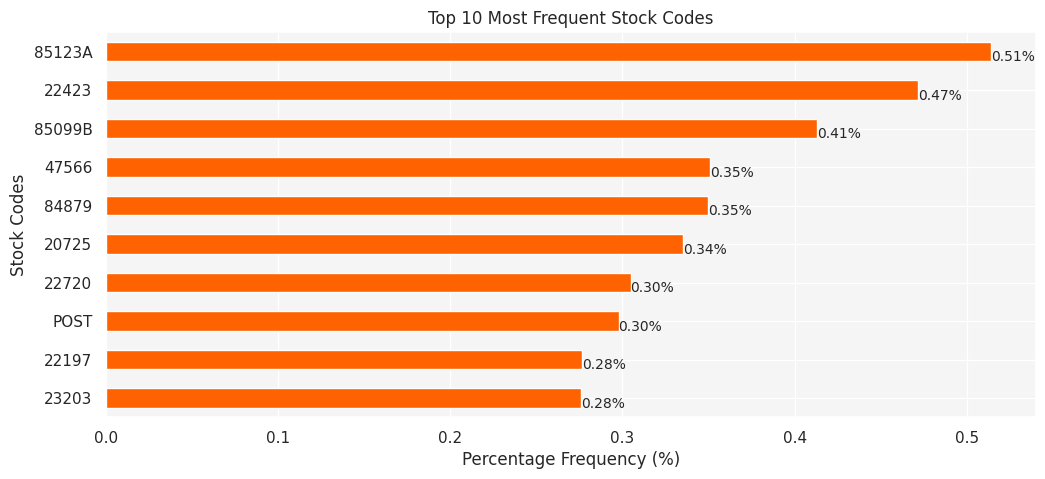

In [ ]:
# Finding the top 10 most frequent stock codes
top_10_stock_codes = df['StockCode'].value_counts(normalize=True).head(10) * 100

# Plotting the top 10 most frequent stock codes
plt.figure(figsize=(12, 5))
top_10_stock_codes.plot(kind='barh', color='#ff6200')

# Adding the percentage frequency on the bars
for index, value in enumerate(top_10_stock_codes):
    plt.text(value, index+0.25, f'{value:.2f}%', fontsize=10)

plt.title('Top 10 Most Frequent Stock Codes')
plt.xlabel('Percentage Frequency (%)')
plt.ylabel('Stock Codes')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Finding the number of numeric characters in each unique stock code
unique_stock_codes = df['StockCode'].unique()
numeric_char_counts_in_unique_codes = pd.Series(unique_stock_codes).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()

# Printing the value counts for unique stock codes
print("Value counts of numeric character frequencies in unique stock codes:")
print("-"*70)
print(numeric_char_counts_in_unique_codes)

Value counts of numeric character frequencies in unique stock codes:
----------------------------------------------------------------------
5    3676
0       7
1       1
Name: count, dtype: int64


In [ ]:
# Finding and printing the stock codes with 0 and 1 numeric characters
anomalous_stock_codes = [code for code in unique_stock_codes if sum(c.isdigit() for c in str(code)) in (0, 1)]

# Printing each stock code on a new line
print("Anomalous stock codes:")
print("-"*22)
for code in anomalous_stock_codes:
    print(code)

Anomalous stock codes:
----------------------
POST
D
C2
M
BANK CHARGES
PADS
DOT
CRUK


In [ ]:
# Calculating the percentage of records with these stock codes
percentage_anomalous = (df['StockCode'].isin(anomalous_stock_codes).sum() / len(df)) * 100
print(f"The percentage of records with anomalous stock codes in the dataset is: {percentage_anomalous:.2f}%")

The percentage of records with anomalous stock codes in the dataset is: 0.48%


In [ ]:
# Removing rows with anomalous stock codes from the dataset
df = df[~df['StockCode'].isin(anomalous_stock_codes)]

In [ ]:
# Calculating the percentage of records with these stock codes
percentage_anomalous = (df['StockCode'].isin(anomalous_stock_codes).sum() / len(df)) * 100
print(f"The percentage of records with anomalous stock codes in the dataset is: {percentage_anomalous:.2f}%")

The percentage of records with anomalous stock codes in the dataset is: 0.00%


In [ ]:
# Getting the number of rows in the dataframe
df.shape[0]

399689

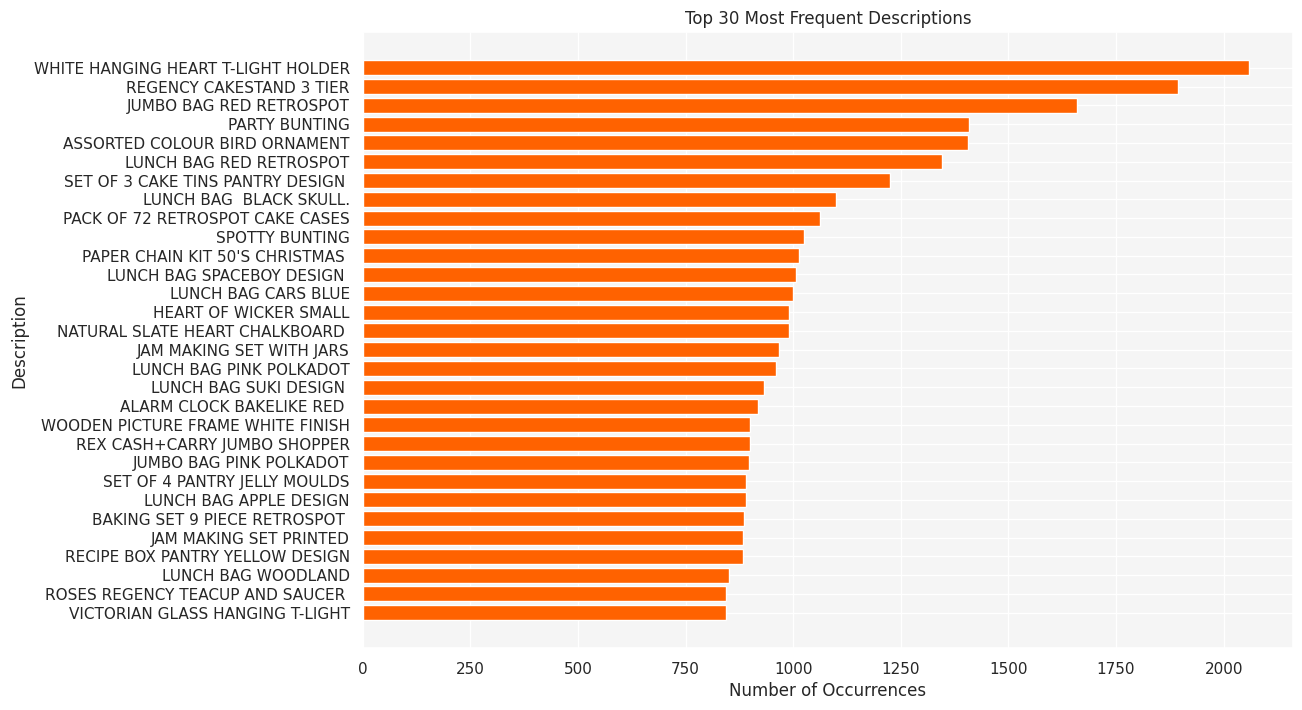

In [ ]:
#====> DESCRIPTION CLEANING

# Calculate the occurrence of each unique description and sort them
description_counts = df['Description'].value_counts()

# Get the top 30 descriptions
top_30_descriptions = description_counts[:30]

# Plotting
plt.figure(figsize=(12,8))
plt.barh(top_30_descriptions.index[::-1], top_30_descriptions.values[::-1], color='#ff6200')

# Adding labels and title
plt.xlabel('Number of Occurrences')
plt.ylabel('Description')
plt.title('Top 30 Most Frequent Descriptions')
plt.show()

In [ ]:
# Find unique descriptions containing lowercase characters
lowercase_descriptions = df['Description'].unique()
lowercase_descriptions = [desc for desc in lowercase_descriptions if any(char.islower() for char in desc)]

# Print the unique descriptions containing lowercase characters
print("The unique descriptions containing lowercase characters are:")
print("-"*60)
for desc in lowercase_descriptions:
    print(desc)

The unique descriptions containing lowercase characters are:
------------------------------------------------------------
BAG 500g SWIRLY MARBLES
POLYESTER FILLER PAD 45x45cm
POLYESTER FILLER PAD 45x30cm
POLYESTER FILLER PAD 40x40cm
FRENCH BLUE METAL DOOR SIGN No
BAG 250g SWIRLY MARBLES
BAG 125g SWIRLY MARBLES
3 TRADITIONAl BISCUIT CUTTERS  SET
NUMBER TILE COTTAGE GARDEN No
FOLK ART GREETING CARD,pack/12
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
POLYESTER FILLER PAD 65CMx65CM
NUMBER TILE VINTAGE FONT No 
POLYESTER FILLER PAD 30CMx30CM
POLYESTER FILLER PAD 60x40cm
FLOWERS HANDBAG blue and orange
Next Day Carriage
THE KING GIFT BAG 25x24x12cm
High Resolution Image


 Interpretation of lowercase analysis results:
------------------------------------------------
 | Type                 | Meaning                      |
 |---------------------|------------------------------|
 | lowercase in product | Normal  (valid product text) |
 | mixed case          | Formatting issue           |
 | service descriptions| Not products               |
 ------------------------------------------------
 upper case + clean products + services + etc

In [ ]:
service_related_descriptions = ["Next Day Carriage", "High Resolution Image"]

# Calculate the percentage of records with service-related descriptions
service_related_percentage = df[df['Description'].isin(service_related_descriptions)].shape[0] / df.shape[0] * 100

# Print the percentage of records with service-related descriptions
print(f"The percentage of records with service-related descriptions in the dataset is: {service_related_percentage:.2f}%")

# Remove rows with service-related information in the description
df = df[~df['Description'].isin(service_related_descriptions)]

# Standardize the text to uppercase to maintain uniformity across the dataset
df['Description'] = df['Description'].str.upper()

The percentage of records with service-related descriptions in the dataset is: 0.02%


In [ ]:
df.shape[0]

399606

In [ ]:
#====> UNIT PRICE ANOMALIES
df['UnitPrice'].describe()

,UnitPrice
count,399606.000000
mean,2.904957
std,4.448796
min,0.000000
25%,1.250000
50%,1.950000
75%,3.750000
max,649.500000


In [ ]:
# Negative prices (2 rows) are clear data-entry errors.
neg_price = (df['UnitPrice'] < 0).sum()
df = df[df['UnitPrice'] >= 0]
print(f"    Negative UnitPrice dropped : {neg_price} rows")

# Zero-price rows on completed (non-cancelled) transactions are ambiguous —
# they could be free samples or data errors.  Since they carry no monetary
# signal and are few, we remove them from the completed-transaction subset.
zero_on_completed = ((df['UnitPrice'] == 0) & (df['Is_Cancelled'] == 0)).sum()
df = df[~((df['UnitPrice'] == 0) & (df['Is_Cancelled'] == 0))]
print(f"    Zero UnitPrice (completed) : {zero_on_completed} rows dropped")


    Negative UnitPrice dropped : 0 rows
    Zero UnitPrice (completed) : 33 rows dropped


In [ ]:
#=====> QUANTITY ANOMALIES

# Non-cancelled rows with negative quantities are unmatched stock corrections,
# not real purchases.  They are distinct from proper cancellations (which start
# with 'C') and should not pollute the purchase-behavior features.
before = len(df)
bad_qty = (df['Is_Cancelled'] == 0) & (df['Quantity'] <= 0)
df = df[~bad_qty]
print(f"    Non-cancelled negative/zero qty rows dropped : {before - len(df):,}")


    Non-cancelled negative/zero qty rows dropped : 0


In [ ]:
# Resetting the index of the cleaned dataset
df.reset_index(drop=True, inplace=True)

In [ ]:
# Getting the number of rows in the dataframe
df.shape[0]

399573

# Feature Engineering

In [ ]:
import datetime as dt

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Total_Price'] = df['Quantity'] * df['UnitPrice']
df['Is_Cancelled'] = df['InvoiceNo'].astype(str).str.startswith('C').astype(int)
df['Is_UK'] = (df['Country'] == 'United Kingdom').astype(int)

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

cust_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Total_Price', 'sum'),
    Product_Diversity=('StockCode', 'nunique'),
    Total_Cancellations=('Is_Cancelled', 'sum'),
    Is_UK=('Is_UK', 'max')
).reset_index()

cust_df['Average_Order_Value'] = cust_df['Monetary'] / cust_df['Frequency']
cust_df['Return_Rate'] = cust_df['Total_Cancellations'] / cust_df['Frequency']

In [ ]:
print(f"Data shape after Feature Engineering: {cust_df.shape}")
display(cust_df.head())

Data shape after Feature Engineering: (4362, 9)


,CustomerID,Recency,Frequency,Monetary,Product_Diversity,Total_Cancellations,Is_UK,Average_Order_Value,Return_Rate
0,12346,326,2,0.00,1,1,1,0.000000,0.5
1,12347,2,7,4310.00,103,0,0,615.714286,0.0
2,12348,75,4,1437.24,21,0,0,359.310000,0.0
3,12349,19,1,1457.55,72,0,0,1457.550000,0.0
4,12350,310,1,294.40,16,0,0,294.400000,0.0


In [ ]:
import datetime as dt
import numpy as np

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Total_Price'] = df['Quantity'] * df['UnitPrice']
df['Is_Cancelled'] = df['InvoiceNo'].astype(str).str.startswith('C').astype(int)
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

def get_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else x.iloc[0]

cust_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Total_Price', 'sum'),
    Unique_Products_Purchased=('StockCode', 'nunique'),
    Total_Cancellations=('Is_Cancelled', 'sum'),
    First_Purchase=('InvoiceDate', 'min'),
    Last_Purchase=('InvoiceDate', 'max'),
    Favorite_Shopping_Hour=('Hour', get_mode),
    Favorite_Shopping_Day=('DayOfWeek', get_mode)
).reset_index()

cust_df['Average_Transaction_Value'] = cust_df['Monetary'] / cust_df['Frequency']
cust_df['Cancellation_Rate'] = cust_df['Total_Cancellations'] / cust_df['Frequency']
cust_df['Tenure'] = (cust_df['Last_Purchase'] - cust_df['First_Purchase']).dt.days
cust_df['Average_Days_Between_Purchases'] = np.where(cust_df['Frequency'] > 1, cust_df['Tenure'] / (cust_df['Frequency'] - 1), 0)

recent_30_days = df[df['InvoiceDate'] >= (snapshot_date - dt.timedelta(days=30))].groupby('CustomerID')['Total_Price'].sum().reset_index()
recent_30_days.rename(columns={'Total_Price': 'Recent_Spend'}, inplace=True)
cust_df = cust_df.merge(recent_30_days, on='CustomerID', how='left').fillna(0)

cust_df['Avg_Monthly_Spend'] = cust_df['Monetary'] / ((cust_df['Tenure'] / 30) + 1)
cust_df['Spending_Trend'] = np.where(cust_df['Avg_Monthly_Spend'] > 0, cust_df['Recent_Spend'] / cust_df['Avg_Monthly_Spend'], 0)

cust_df.drop(columns=['Total_Cancellations', 'First_Purchase', 'Last_Purchase', 'Tenure', 'Recent_Spend', 'Avg_Monthly_Spend'], inplace=True)

In [ ]:
print(f"Total Customers: {cust_df.shape[0]}")
print(f"Total Features: {cust_df.shape[1]}")
print("\n--- Summary Statistics ---")
print(cust_df[['Recency', 'Frequency', 'Monetary', 'Spending_Trend']].describe().loc[['mean', '50%', 'max']])
print("\n--- First 5 Rows ---")
cust_df.head()

Total Customers: 4362
Total Features: 11

--- Summary Statistics ---
         Recency   Frequency       Monetary  Spending_Trend
mean   92.172627    4.993352    1894.604523   -3.178538e+13
50%    50.000000    3.000000     641.785000    0.000000e+00
max   374.000000  242.000000  278778.020000    1.389984e+01

--- First 5 Rows ---


,CustomerID,Recency,Frequency,Monetary,Unique_Products_Purchased,Favorite_Shopping_Hour,Favorite_Shopping_Day,Average_Transaction_Value,Cancellation_Rate,Average_Days_Between_Purchases,Spending_Trend
0,12346,326,2,0.00,1,10,Tuesday,0.000000,0.5,0.000000,0.000000
1,12347,2,7,4310.00,103,14,Tuesday,615.714286,0.0,60.833333,0.686805
2,12348,75,4,1437.24,21,19,Thursday,359.310000,0.0,94.000000,0.000000
3,12349,19,1,1457.55,72,9,Monday,1457.550000,0.0,0.000000,1.000000
4,12350,310,1,294.40,16,16,Wednesday,294.400000,0.0,0.000000,0.000000


# prep

In [ ]:
print("\n[11] Outlier Treatment on Customer Features")

exclude_cols = ['CustomerID', 'Is_UK', 'Favorite_Shopping_Hour', 'Favorite_Shopping_Day']
numeric_feats = [c for c in cust_df.select_dtypes(include=['number']).columns if c not in exclude_cols]

def iqr_cap(series, lower_q=0.01, upper_q=0.99):
    lo = series.quantile(lower_q)
    hi = series.quantile(upper_q)
    return series.clip(lo, hi)

before_stats = cust_df[numeric_feats].describe().loc[['min', 'max']]
for col in numeric_feats:
    cust_df[col] = iqr_cap(cust_df[col])
after_stats = cust_df[numeric_feats].describe().loc[['min', 'max']]

print("    IQR winsorisation applied (1st – 99th pct) to all numeric features.")
print("    Before → After range for key columns:")
for col in ['Recency', 'Monetary', 'Frequency']:
    b_min, b_max = before_stats[col]['min'], before_stats[col]['max']
    a_min, a_max = after_stats[col]['min'],  after_stats[col]['max']
    print(f"      {col:<18}: [{b_min:.1f}, {b_max:.1f}]  →  [{a_min:.1f}, {a_max:.1f}]")


[11] Outlier Treatment on Customer Features
    IQR winsorisation applied (1st – 99th pct) to all numeric features.
    Before → After range for key columns:
      Recency           : [1.0, 374.0]  →  [1.0, 369.0]
      Monetary          : [-1192.2, 278778.0]  →  [3.4, 17024.2]
      Frequency         : [1.0, 242.0]  →  [1.0, 35.4]


In [ ]:
# Getting the number of rows in the cleaned customer dataset
cust_df.shape[0]

4362

df (transactions)  →  cust_df (customers)
  
| 399k rows         →→→→          4362 rows |

In [ ]:

#===> CORRELATION CHECK
corr_matrix = cust_df[numeric_feats].corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))
if high_corr_pairs:
    print(f"    Highly correlated pairs (|r| > 0.85): {high_corr_pairs}")
    print("    → PCA in the next step will handle multicollinearity.")
else:
    print("    No pairs with |r| > 0.85 detected.")


    No pairs with |r| > 0.85 detected.



[13] Correlation Matrix


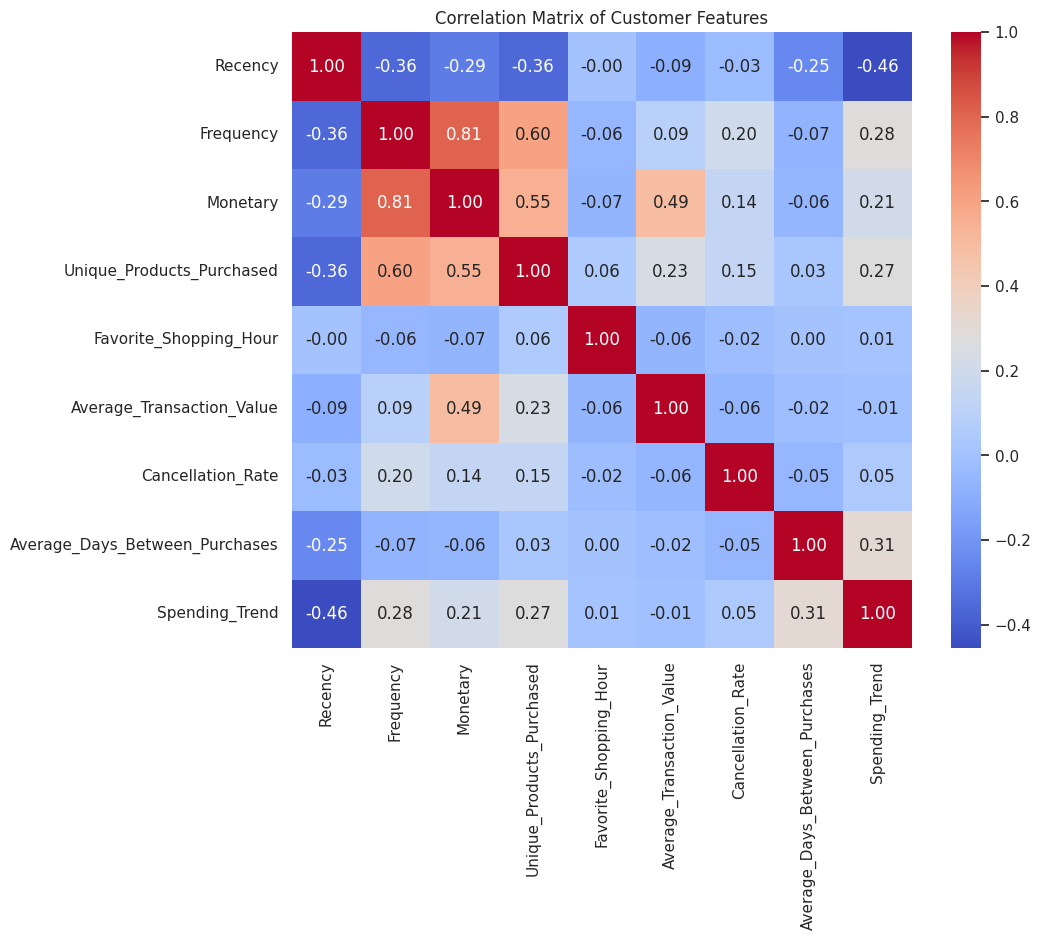

In [ ]:
print("\n[13] Correlation Matrix")
plt.figure(figsize=(10, 8))

numeric_df = cust_df.select_dtypes(include=['number']).drop('CustomerID', axis=1, errors='ignore')
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Customer Features')
plt.show()

The correlation analysis showed moderate positive correlation between Frequency and Monetary (r = 0.81), indicating that frequent customers tend to spend more. No severe multicollinearity was detected, as no correlation exceeded the 0.85 threshold.

# clustering and eval

In [ ]:
numeric_df

In [ ]:
import numpy as np

data_log = numeric_df.copy()
skew_features = [
    'Monetary',
    'Frequency',
    'Average_Transaction_Value',
    'Spending_Trend',
    'Recency'
]

for col in skew_features:
    if col in data_log.columns:
        data_log[col] = np.log1p(data_log[col])

In [ ]:
data_log

,Recency,Frequency,Monetary,Unique_Products_Purchased,Favorite_Shopping_Hour,Average_Transaction_Value,Cancellation_Rate,Average_Days_Between_Purchases,Spending_Trend
0,5.789960,1.098612,1.485800,1.0,10,1.298692,0.500000,0.000000,0.000000
1,1.098612,2.079442,8.368925,103.0,14,6.424406,0.000000,60.833333,0.522836
2,4.330733,1.609438,7.271175,21.0,19,5.886965,0.000000,94.000000,0.000000
3,2.995732,0.693147,7.285198,72.0,9,7.285198,0.000000,0.000000,0.693147
4,5.739793,0.693147,5.688330,16.0,16,5.688330,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
4357,5.631212,0.693147,5.201806,10.0,9,5.201806,0.000000,0.000000,0.000000
4358,5.204007,0.693147,4.404522,7.0,10,4.404522,0.000000,0.000000,0.000000
4359,2.197225,1.386294,5.179534,12.0,13,4.092120,0.333333,59.000000,1.155139
4360,1.609438,2.833213,7.620989,262.0,14,4.855725,0.000000,22.200000,1.794631


feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler,RobustScaler


data_scaled = data_log.copy()




features = data_scaled.columns



scaler = RobustScaler()
scaled_values = scaler.fit_transform(data_scaled[features])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=features,
    index=data_scaled.index
)

print("Scaled Data Shape:", scaled_df.shape)
scaled_df.head()

Scaled Data Shape: (4362, 9)


,Recency,Frequency,Monetary,Unique_Products_Purchased,Favorite_Shopping_Hour,Average_Transaction_Value,Cancellation_Rate,Average_Days_Between_Purchases,Spending_Trend
0,0.893574,-0.261860,-2.951351,-0.548387,-0.666667,-4.744136,1.833333,-0.413793,0.000000
1,-1.362488,0.630930,1.127861,1.096774,0.666667,1.082526,0.000000,0.635057,0.712361
2,0.191834,0.203114,0.477291,-0.225806,2.333333,0.471589,0.000000,1.206897,0.000000
3,-0.450166,-0.630930,0.485602,0.596774,-1.000000,2.061033,0.000000,-0.413793,0.944408
4,0.869448,-0.630930,-0.460765,-0.306452,1.333333,0.245791,0.000000,-0.413793,0.000000


PCA

In [ ]:
from sklearn.decomposition import PCA

# PCA على الـ numeric features فقط
pca = PCA(n_components=6)

pca_result = pca.fit_transform(scaled_df[features])

# DataFrame النهائي
customer_data_pca = pd.DataFrame(
    pca_result,
    columns=[f'PC{i+1}' for i in range(6)]
)

print("PCA Shape:", customer_data_pca.shape)
customer_data_pca.head()

PCA Shape: (4362, 6)


,PC1,PC2,PC3,PC4,PC5,PC6
0,1.046206,-4.517515,0.970352,-2.811110,-1.139516,1.899171
1,-0.639530,2.131281,0.028916,0.101269,0.298749,-0.615577
2,-1.019818,0.112274,0.502700,0.362056,2.111446,-0.826578
3,-1.012232,1.218443,-1.195425,1.180912,-1.021267,-0.598503
4,-1.154136,-1.115371,-0.855037,-0.007924,1.147232,-0.500462


Explained Variance

In [ ]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.40029739 0.24316936 0.11244077 0.08431785 0.0658828  0.05355967]

Total Variance Explained:
0.9596678587719768


K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans


kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=50,
    max_iter=500,
    random_state=42
)

clusters = kmeans.fit_predict(customer_data_pca)

customer_data_pca['Cluster'] = clusters

customer_data_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,Cluster
0,1.046206,-4.517515,0.970352,-2.811110,-1.139516,1.899171,2
1,-0.639530,2.131281,0.028916,0.101269,0.298749,-0.615577,0
2,-1.019818,0.112274,0.502700,0.362056,2.111446,-0.826578,2
3,-1.012232,1.218443,-1.195425,1.180912,-1.021267,-0.598503,0
4,-1.154136,-1.115371,-0.855037,-0.007924,1.147232,-0.500462,2


Elbow Method

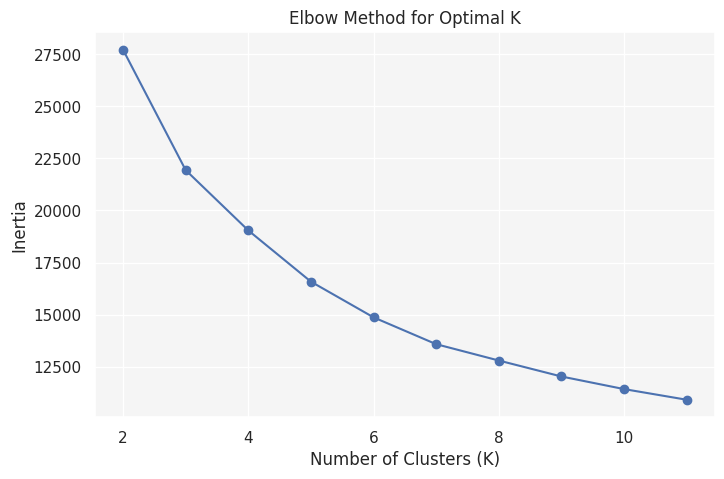

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 12)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(customer_data_pca.drop('Cluster', axis=1, errors='ignore'))
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

Silhouette Score

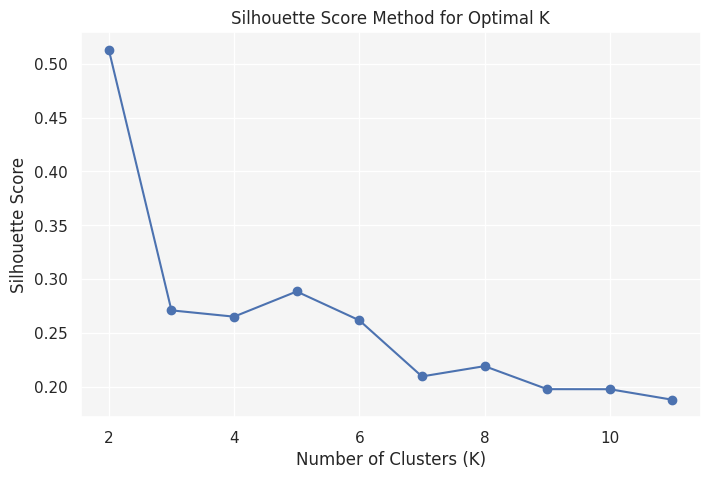

Best K from Silhouette: 2


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
K_range = range(2, 12)

X = customer_data_pca.drop('Cluster', axis=1, errors='ignore')

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method for Optimal K')
plt.show()

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print("Best K from Silhouette:", best_k)

Final KMeans Model (على أفضل K)

In [ ]:
kmeans_final = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)

customer_data_pca['Cluster'] = kmeans_final.fit_predict(X)

customer_data_pca['Cluster'].value_counts()

Cluster
2    2280
0    1701
1     381
Name: count, dtype: int64

Visualization(PCA 2D)

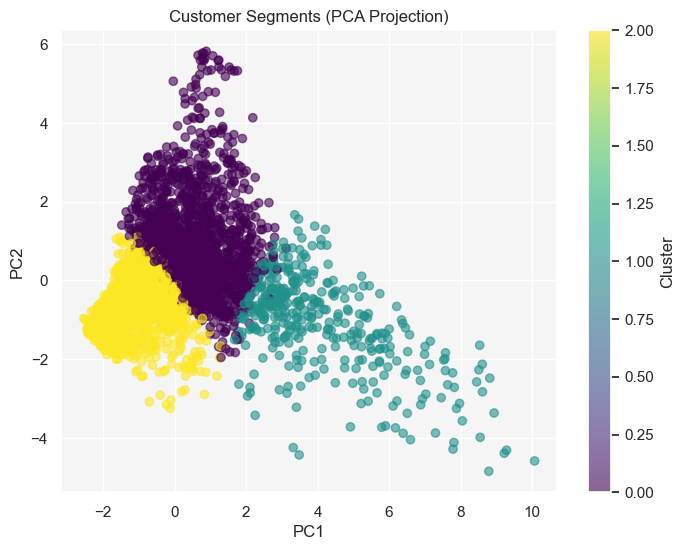

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    customer_data_pca['PC1'],
    customer_data_pca['PC2'],
    c=customer_data_pca['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments (PCA Projection)')
plt.colorbar(label='Cluster')
plt.show()

3D Scatter (Plotly Interactive)

In [ ]:
# import plotly.express as px

# fig = px.scatter_3d(
#     customer_data_pca,
#     x='PC1',
#     y='PC2',
#     z='PC3',
#     color='Cluster',
#     opacity=0.7,
#     title='3D Customer Segments (PCA Space)'
# )

# fig.show()

Cluster Distribution (Percentages

In [ ]:
cluster_counts = customer_data_pca['Cluster'].value_counts(normalize=True) * 100
cluster_counts = cluster_counts.sort_index()

print("Cluster Distribution (%):")
print(cluster_counts)

Cluster Distribution (%):
Cluster
0    38.995873
1     8.734525
2    52.269601
Name: proportion, dtype: float64


Evaluation Metrics (Final Clean Code)

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

X = customer_data_pca.drop('Cluster', axis=1)

sil = silhouette_score(X, customer_data_pca['Cluster'])
ch = calinski_harabasz_score(X, customer_data_pca['Cluster'])
db = davies_bouldin_score(X, customer_data_pca['Cluster'])

print("Silhouette Score:", round(sil, 3))
print("Calinski-Harabasz Score:", round(ch, 3))
print("Davies-Bouldin Score:", round(db, 3))

Silhouette Score: 0.207
Calinski-Harabasz Score: 1162.607
Davies-Bouldin Score: 1.622


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Is_Cancelled,Total_Price,Is_UK,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,0,15.30,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,20.34,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,0,22.00,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,20.34,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,20.34,1,8,Wednesday


# Profiling (Cluster Ananlysis)

In [ ]:
# Add Cluster Labels to Original Customer Data

cust_df['Cluster'] = customer_data_pca['Cluster'].values

print(cust_df[['CustomerID', 'Cluster']].head())


  CustomerID  Cluster
0      12346        2
1      12347        0
2      12348        0
3      12349        0
4      12350        2


In [ ]:
# Check Cluster Sizes

cluster_sizes = cust_df['Cluster'].value_counts().sort_index()

print(cluster_sizes)

Cluster
0    1701
1     381
2    2280
Name: count, dtype: int64


## Visualize Cluster Distribution

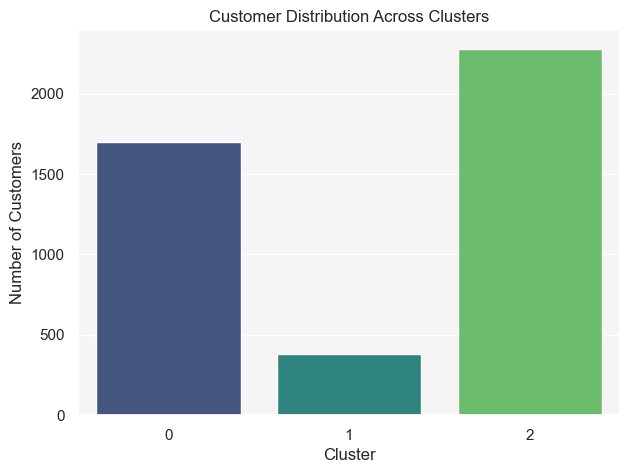

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.countplot(
    data=cust_df,
    x='Cluster',
    palette='viridis'
)

plt.title('Customer Distribution Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()


# Cluster Profiling Table


In [ ]:
cluster_profile = cust_df.groupby('Cluster').agg({

    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Unique_Products_Purchased': 'mean',
    'Average_Transaction_Value': 'mean',
    'Cancellation_Rate': 'mean',
    'Average_Days_Between_Purchases': 'mean',
    'Spending_Trend': 'mean',
    'Favorite_Shopping_Hour': 'mean'

}).round(2)

cluster_profile

,Recency,Frequency,Monetary,Unique_Products_Purchased,Average_Transaction_Value,Cancellation_Rate,Average_Days_Between_Purchases,Spending_Trend,Favorite_Shopping_Hour
Cluster,,,,,,,,,
0,31.68,5.19,1464.87,72.81,304.28,0.23,82.36,1.47,12.52
1,17.28,18.59,7584.40,194.93,523.47,0.52,22.23,1.57,12.25
2,149.75,1.99,493.66,26.01,275.16,0.19,15.54,0.10,12.50


## Compare With Overall Average
## HEATMAP

=== Overall Average ===
Recency                             92.14
Frequency                            4.69
Monetary                          1491.73
Unique_Products_Purchased           59.01
Average_Transaction_Value          308.21
Cancellation_Rate                    0.24
Average_Days_Between_Purchases      42.18
Spending_Trend                       0.77
Favorite_Shopping_Hour              12.49
dtype: float64

=== Cluster Profiles ===
         Recency  Frequency  Monetary  Unique_Products_Purchased  \
Cluster                                                            
0          31.68       5.19   1464.87                      72.81   
1          17.28      18.59   7584.40                     194.93   
2         149.75       1.99    493.66                      26.01   

         Average_Transaction_Value  Cancellation_Rate  \
Cluster                                                 
0                           304.28               0.23   
1                           523.47           

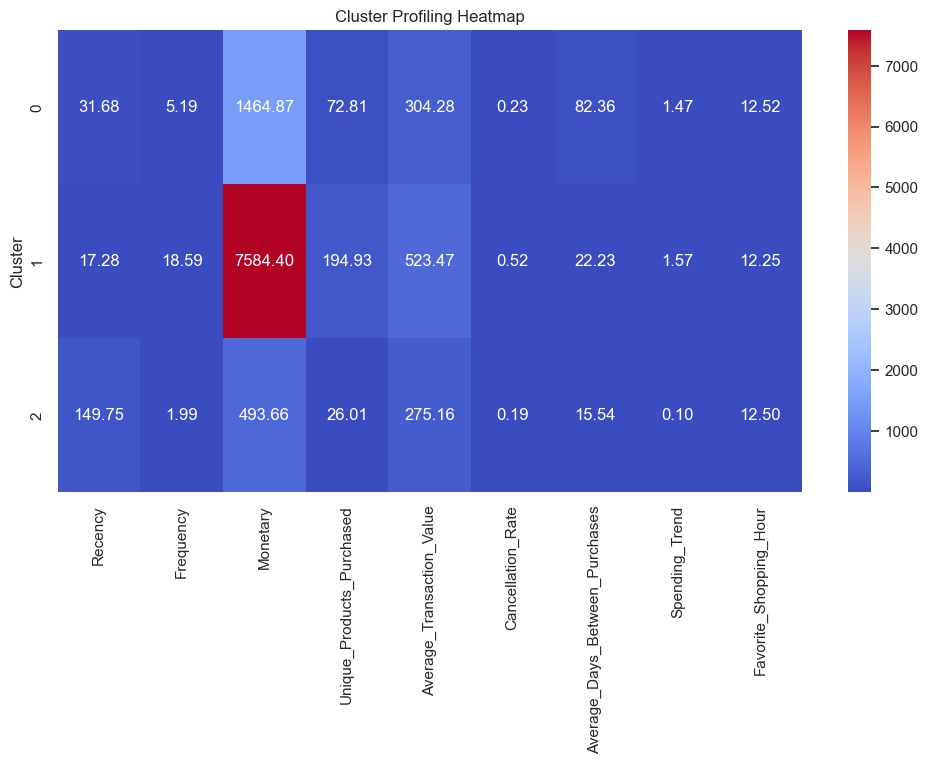

In [ ]:
overall_avg = cust_df[[
    'Recency',
    'Frequency',
    'Monetary',
    'Unique_Products_Purchased',
    'Average_Transaction_Value',
    'Cancellation_Rate',
    'Average_Days_Between_Purchases',
    'Spending_Trend',
    'Favorite_Shopping_Hour'
]].mean().round(2)

print("=== Overall Average ===")
print(overall_avg)

print("\n=== Cluster Profiles ===")
print(cluster_profile)

plt.figure(figsize=(12,6))
sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Cluster Profiling Heatmap')

plt.show()

## RENDER CHART


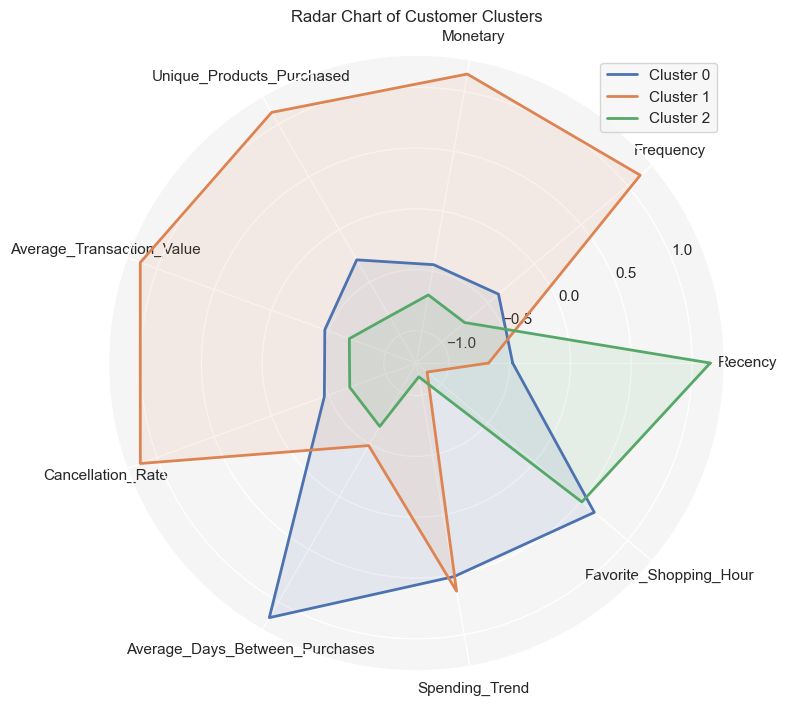

In [ ]:
import numpy as np
# standarize data
radar_data = cluster_profile.copy()

radar_data = (
    radar_data - radar_data.mean()
) / radar_data.std()

radar_data

categories = radar_data.columns.tolist()
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw=dict(polar=True)
)

for cluster in radar_data.index:

    values = radar_data.loc[cluster].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f'Cluster {cluster}'
    )

    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title('Radar Chart of Customer Clusters')

plt.legend(loc='upper right')

plt.show()

## Monetary distribution

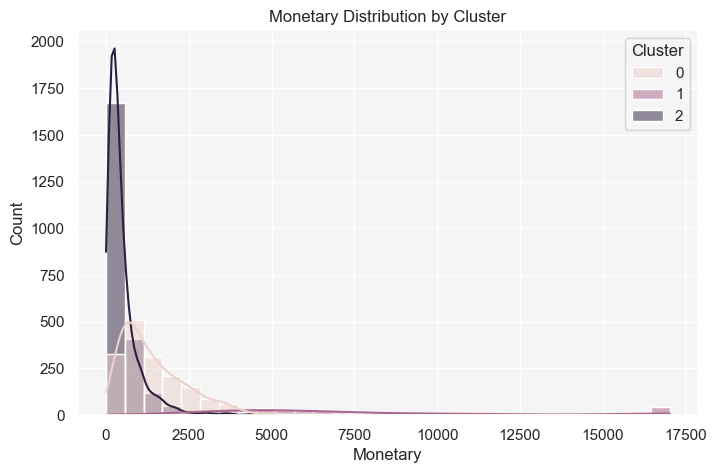

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=cust_df,
    x='Monetary',
    hue='Cluster',
    bins=30,
    kde=True
)

plt.title('Monetary Distribution by Cluster')

plt.show()

## Frequency Distribution


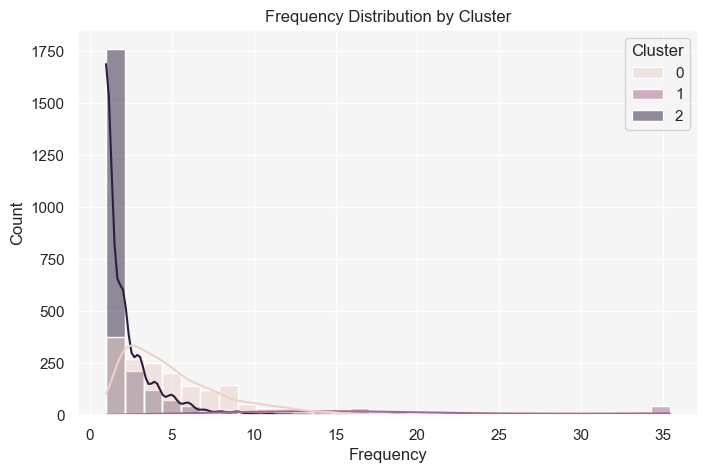

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=cust_df,
    x='Frequency',
    hue='Cluster',
    bins=30,
    kde=True
)

plt.title('Frequency Distribution by Cluster')

plt.show()

## Box Plots (important features)

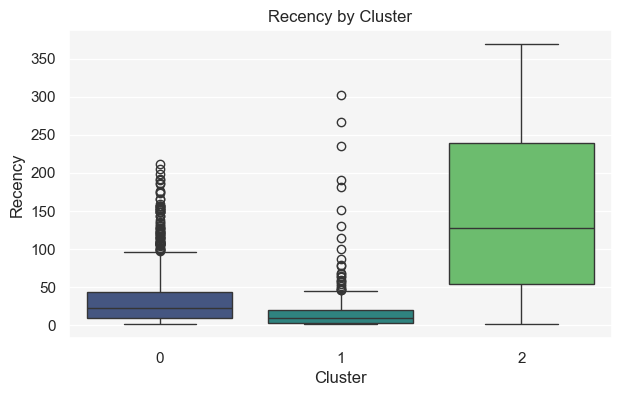

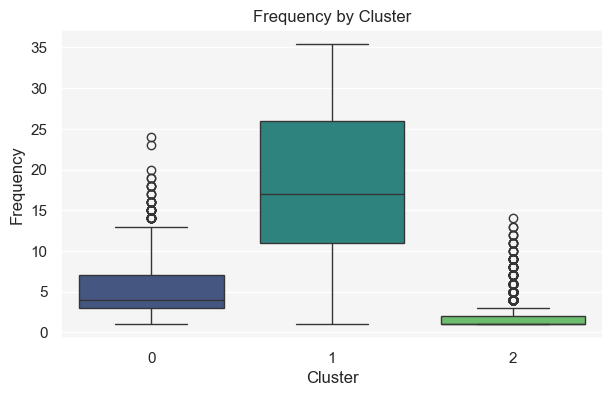

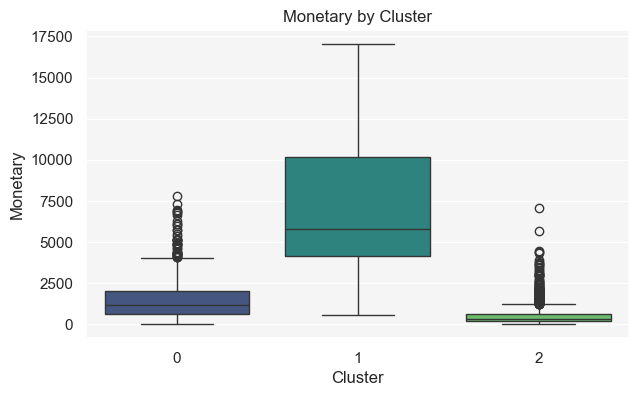

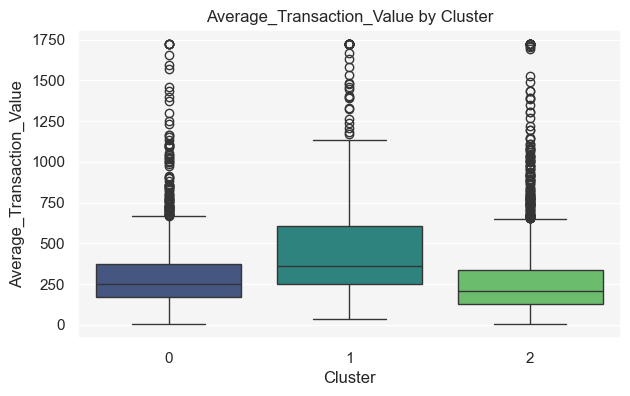

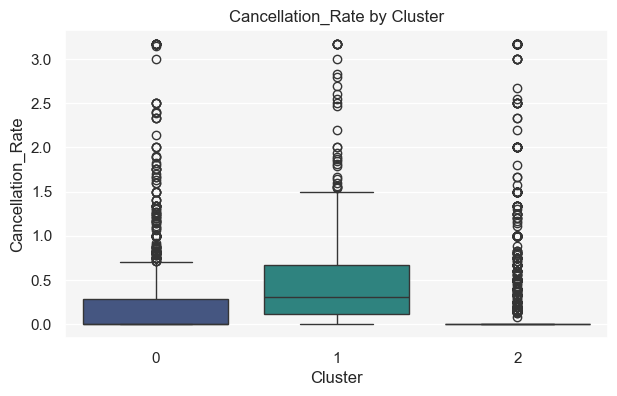

In [ ]:
features_to_plot = [

    'Recency',
    'Frequency',
    'Monetary',
    'Average_Transaction_Value',
    'Cancellation_Rate'

]

for feature in features_to_plot:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=cust_df,
        x='Cluster',
        y=feature,
        palette='viridis'
    )

    plt.title(f'{feature} by Cluster')

    plt.show()


# Recommendation System

In [ ]:
# توحيد نوع CustomerID

df['CustomerID'] = df['CustomerID'].astype(str)
cust_df['CustomerID'] = cust_df['CustomerID'].astype(str)

# إضافة الـ cluster لكل transaction

df = df.merge(

    cust_df[['CustomerID', 'Cluster']],
    on='CustomerID',
    how='left'


)

df[['CustomerID', 'Cluster']].head()

,CustomerID,Cluster
0,17850,1
1,17850,1
2,17850,1
3,17850,1
4,17850,1


## Excluding customers (money-based)

In [ ]:
## filtering using IQR
Q1 = cust_df['Monetary'].quantile(0.25)
Q3 = cust_df['Monetary'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -1646.1862500000002
Upper Bound: 3523.30375


In [ ]:
filtered_customers = cust_df[

    (cust_df['Monetary'] >= lower_bound) &
    (cust_df['Monetary'] <= upper_bound)

].copy()

filtered_customers.shape

(3942, 12)

In [ ]:
filtered_recommend_df = df.merge(

    filtered_customers[['CustomerID']],
    on='CustomerID',
    how='inner'

)

filtered_recommend_df.shape

(239737, 14)

## Top 10 Products


In [ ]:
top_products_per_cluster = (

    filtered_recommend_df
    .groupby(

        ['Cluster', 'StockCode', 'Description']

    )['Quantity']
    .sum()
    .reset_index()

)

top_products_per_cluster.head()

,Cluster,StockCode,Description,Quantity
0,0,10002,INFLATABLE POLITICAL GLOBE,127
1,0,10080,GROOVY CACTUS INFLATABLE,215
2,0,10120,DOGGY RUBBER,88
3,0,10123C,HEARTS WRAPPING TAPE,1
4,0,10124A,SPOTS ON RED BOOKCOVER TAPE,1


## Sort Products

In [ ]:
top_products_per_cluster = (

    top_products_per_cluster
    .sort_values(

        ['Cluster', 'Quantity'],
        ascending=[True, False]

    )
)

In [ ]:
top_10_products = (

    top_products_per_cluster
    .groupby('Cluster')
    .head(10)

)

top_10_products

,Cluster,StockCode,Description,Quantity
29,0,16014,SMALL CHINESE STYLE SCISSOR,12854
2860,0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,12376
3093,0,84879,ASSORTED COLOUR BIRD ORNAMENT,9748
3268,0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,7801
404,0,21212,PACK OF 72 RETROSPOT CAKE CASES,7127
3253,0,85099B,JUMBO BAG RED RETROSPOT,7125
1927,0,23084,RABBIT NIGHT LIGHT,6389
70,0,17003,BROCADE RING PURSE,5777
3026,0,84755,COLOUR GLASS T-LIGHT HOLDER HANGING,5329
1042,0,22178,VICTORIAN GLASS HANGING T-LIGHT,5205


## Visualize Top 10

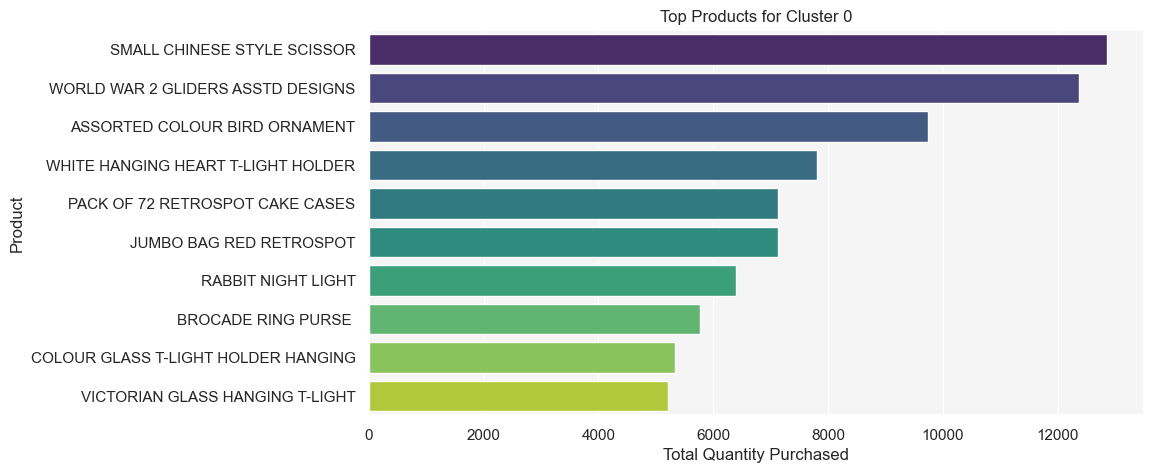

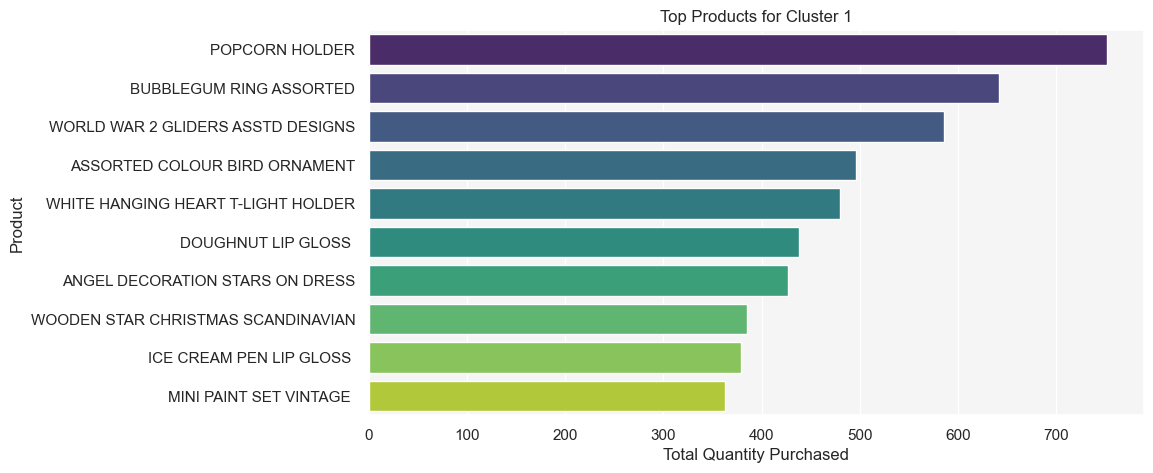

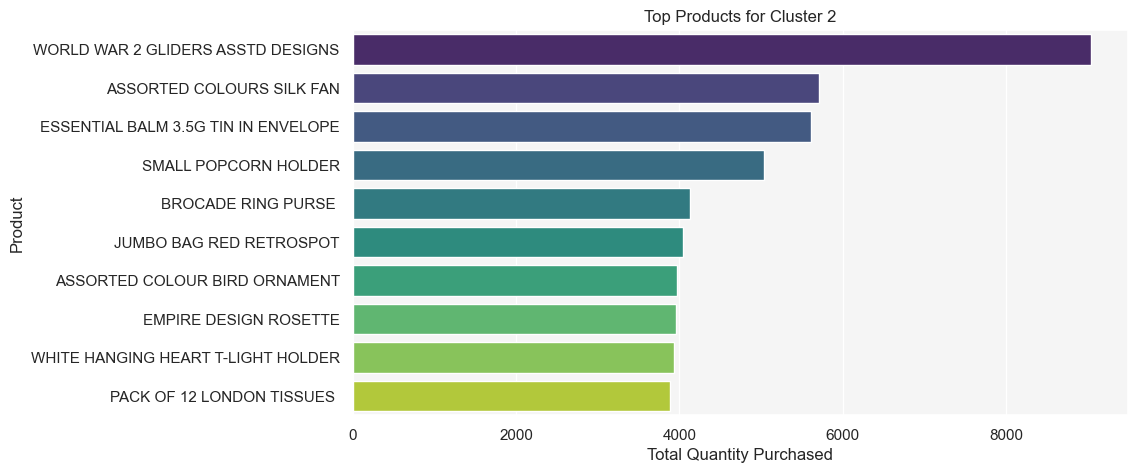

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for cluster in sorted(top_10_products['Cluster'].unique()):

    plt.figure(figsize=(10,5))

    cluster_data = top_10_products[
        top_10_products['Cluster'] == cluster
    ]

    sns.barplot(

        data=cluster_data,
        x='Quantity',
        y='Description',
        palette='viridis'

    )

    plt.title(f'Top Products for Cluster {cluster}')

    plt.xlabel('Total Quantity Purchased')
    plt.ylabel('Product')

    plt.show()

## Lookup


In [ ]:
interaction_df = filtered_recommend_df[[
    'CustomerID',
    'StockCode'
]].drop_duplicates()

interaction_df.head()


,CustomerID,StockCode
0,13047,84879
1,13047,22745
2,13047,22748
3,13047,22749
4,13047,22310


In [ ]:
interaction_df['CustomerID'] = (
    interaction_df['CustomerID']
    .astype(str)
)

interaction_df['StockCode'] = (
    interaction_df['StockCode']
    .astype(str)
)

## Bipartite Graph

In [ ]:
import networkx as nx

B = nx.Graph()

# إضافة customer nodes
customer_nodes = interaction_df['CustomerID'].unique()

B.add_nodes_from(
    customer_nodes,
    bipartite='customers'
)

# إضافة product nodes
product_nodes = interaction_df['StockCode'].unique()

B.add_nodes_from(
    product_nodes,
    bipartite='products'
)

# إضافة edges
edges = list(zip(

    interaction_df['CustomerID'],
    interaction_df['StockCode']

))

B.add_edges_from(edges)

print("Number of Nodes:", B.number_of_nodes())
print("Number of Edges:", B.number_of_edges())

Number of Nodes: 7513
Number of Edges: 190266


In [ ]:
import numpy as np

print(np.__version__)

In [ ]:
import sys

!{sys.executable} -m pip install node2vec --user

  Obtaining dependency information for node2vec from https://files.pythonhosted.org/packages/b9/ca/d3bedf079e1132dfb5c8bcfac721dc11a1cd8064c9472d22ffa2c23c9ce3/node2vec-0.5.0-py3-none-any.whl.metadata
  Using cached node2vec-0.5.0-py3-none-any.whl.metadata (849 bytes)
  Obtaining dependency information for gensim<5.0.0,>=4.3.0 from https://files.pythonhosted.org/packages/10/c3/7e22d6f7d88c4ea6a3a84481f00538252659d285713c3b7e2e1537b0e7e1/gensim-4.4.0-cp311-cp311-win_amd64.whl.metadata
  Using cached gensim-4.4.0-cp311-cp311-win_amd64.whl.metadata (8.6 kB)
Using cached node2vec-0.5.0-py3-none-any.whl (7.2 kB)
Using cached gensim-4.4.0-cp311-cp311-win_amd64.whl (24.4 MB)



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from node2vec import Node2Vec

# إنشاء embeddings
node2vec = Node2Vec(

    B,
    dimensions=64,
    walk_length=20,
    num_walks=100,
    workers=1

)

# تدريب المودل
model = node2vec.fit(

    window=10,
    min_count=1,
    batch_words=4

)

Computing transition probabilities: 100%|██████████| 7513/7513 [02:35<00:00, 48.21it/s] 


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
sample_product = interaction_df['StockCode'].iloc[0]

similar_products = model.wv.most_similar(sample_product)

similar_products[:5]

In [ ]:
product_lookup = (

    filtered_recommend_df[
        ['StockCode', 'Description']
    ]

    .drop_duplicates()

    .set_index('StockCode')['Description']
    .to_dict()

)

In [ ]:
def recommend_gnn_products(customer_id, n_recommendations=5):

    customer_id = str(customer_id)

    # المنتجات التي اشتراها العميل
    purchased_products = interaction_df[

        interaction_df['CustomerID'] == customer_id

    ]['StockCode'].tolist()

    recommended_products = []

    # البحث عن منتجات مشابهة
    for product in purchased_products:

        try:

            similar_items = model.wv.most_similar(
                product,
                topn=10
            )

            for item, score in similar_items:

                if item not in purchased_products:

                    recommended_products.append(item)

        except:
            continue

    # إزالة التكرار
    recommended_products = list(
        dict.fromkeys(recommended_products)
    )

    return recommended_products[:n_recommendations]

## Recommendation Function